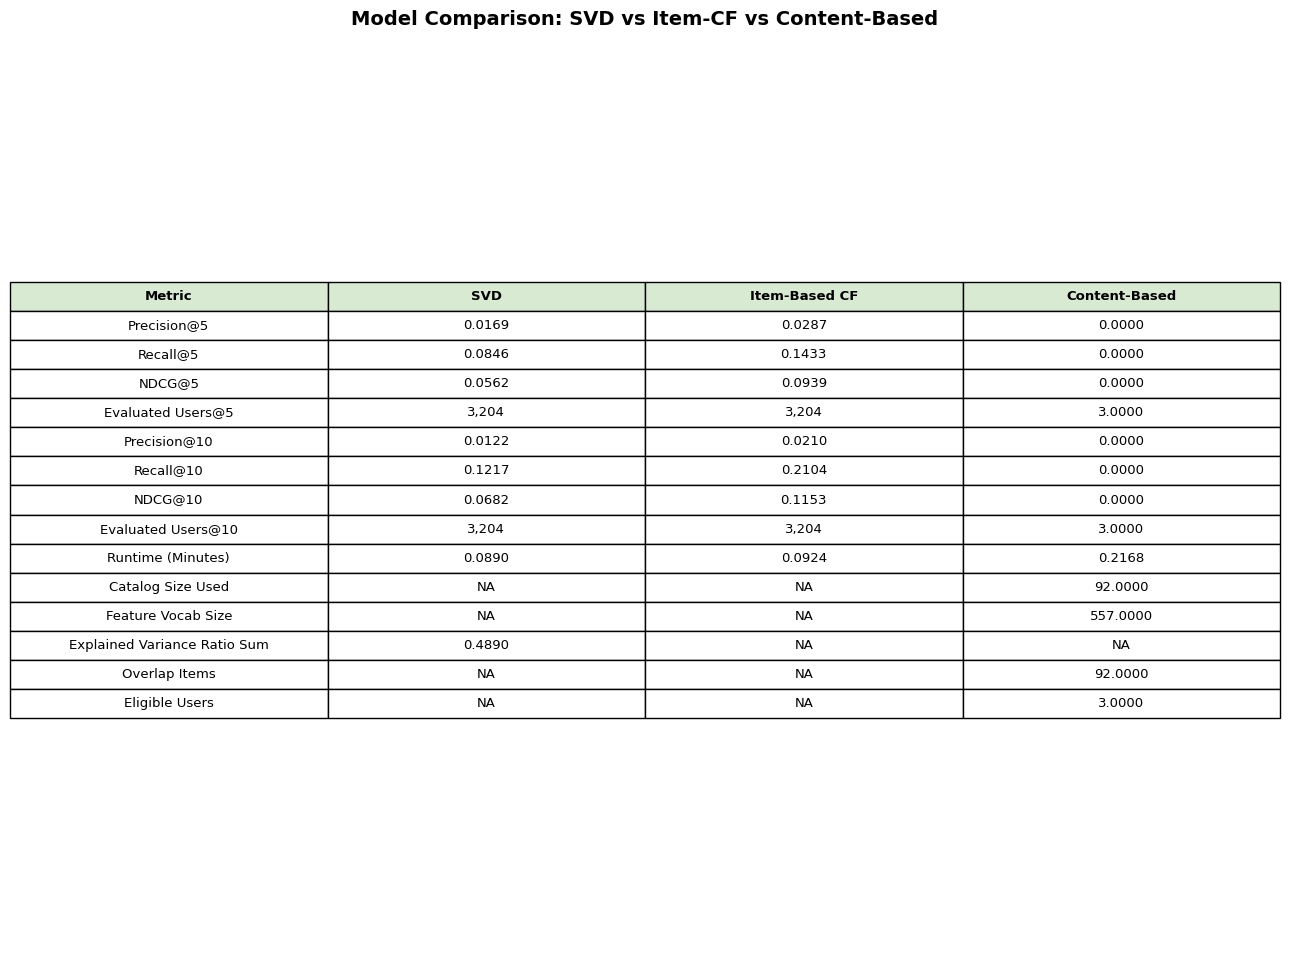

Updated comparison outputs saved:
- C:\Users\barath\recomart-pipeline\reports\model_comparison_table_3_models.csv
- C:\Users\barath\recomart-pipeline\reports\model_comparison_table_3_models.pdf

Preview:
                      Metric    SVD Item-Based CF Content-Based
                 Precision@5 0.0169        0.0287        0.0000
                    Recall@5 0.0846        0.1433        0.0000
                      NDCG@5 0.0562        0.0939        0.0000
           Evaluated Users@5  3,204         3,204        3.0000
                Precision@10 0.0122        0.0210        0.0000
                   Recall@10 0.1217        0.2104        0.0000
                     NDCG@10 0.0682        0.1153        0.0000
          Evaluated Users@10  3,204         3,204        3.0000
           Runtime (Minutes) 0.0890        0.0924        0.2168
           Catalog Size Used     NA            NA       92.0000
          Feature Vocab Size     NA            NA      557.0000
Explained Variance Ratio Sum

In [1]:
# Code Generated by Sidekick is for learning and experimentation purposes only.
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

# ----------------------------
# 1) Locate project folders
# ----------------------------
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORT_ROOT = PROJECT_ROOT / "reports"
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

SVD_METRICS_PATH = REPORT_ROOT / "svd_metrics.json"
ITEM_CF_METRICS_PATH = REPORT_ROOT / "item_cf_metrics.json"
CONTENT_METRICS_PATH = REPORT_ROOT / "content_based_metrics.json"

OUTPUT_CSV_PATH = REPORT_ROOT / "model_comparison_table_3_models.csv"
OUTPUT_PDF_PATH = REPORT_ROOT / "model_comparison_table_3_models.pdf"

# ----------------------------
# 2) Load metrics
# ----------------------------
required_files = [
    SVD_METRICS_PATH,
    ITEM_CF_METRICS_PATH,
    CONTENT_METRICS_PATH,
]

missing_files = [str(p) for p in required_files if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing metrics file(s):\n- " + "\n- ".join(missing_files)
    )

with open(SVD_METRICS_PATH, "r", encoding="utf-8") as f:
    svd_metrics = json.load(f)

with open(ITEM_CF_METRICS_PATH, "r", encoding="utf-8") as f:
    item_cf_metrics = json.load(f)

with open(CONTENT_METRICS_PATH, "r", encoding="utf-8") as f:
    content_metrics = json.load(f)

# ----------------------------
# 3) Build comparison table
# ----------------------------
metric_order = [
    "precision_at_5",
    "recall_at_5",
    "ndcg_at_5",
    "evaluated_users_at_5",
    "precision_at_10",
    "recall_at_10",
    "ndcg_at_10",
    "evaluated_users_at_10",
    "runtime_minutes",
    "catalog_size",
    "catalog_size_used",
    "feature_vocab_size",
    "explained_variance_ratio_sum",
    "overlap_items",
    "eligible_users",
]

comparison_rows = []
for metric in metric_order:
    comparison_rows.append({
        "Metric": metric,
        "SVD": svd_metrics.get(metric, "NA"),
        "Item-Based CF": item_cf_metrics.get(metric, "NA"),
        "Content-Based": content_metrics.get(metric, "NA"),
    })

comparison_df = pd.DataFrame(comparison_rows)

# Keep only rows where at least one model has a real value
comparison_df = comparison_df[
    ~(
        (comparison_df["SVD"] == "NA") &
        (comparison_df["Item-Based CF"] == "NA") &
        (comparison_df["Content-Based"] == "NA")
    )
].copy()

# ----------------------------
# 4) Pretty formatting
# ----------------------------
display_df = comparison_df.copy()

def fmt_value(x):
    if isinstance(x, (int, float)) and not isinstance(x, bool):
        if abs(float(x)) >= 1000:
            return f"{x:,.0f}"
        return f"{x:.4f}"
    return str(x)

for col in ["SVD", "Item-Based CF", "Content-Based"]:
    display_df[col] = display_df[col].apply(fmt_value)

display_df["Metric"] = display_df["Metric"].replace({
    "precision_at_5": "Precision@5",
    "recall_at_5": "Recall@5",
    "ndcg_at_5": "NDCG@5",
    "evaluated_users_at_5": "Evaluated Users@5",
    "precision_at_10": "Precision@10",
    "recall_at_10": "Recall@10",
    "ndcg_at_10": "NDCG@10",
    "evaluated_users_at_10": "Evaluated Users@10",
    "runtime_minutes": "Runtime (Minutes)",
    "catalog_size": "Catalog Size",
    "catalog_size_used": "Catalog Size Used",
    "feature_vocab_size": "Feature Vocab Size",
    "explained_variance_ratio_sum": "Explained Variance Ratio Sum",
    "overlap_items": "Overlap Items",
    "eligible_users": "Eligible Users",
})

# ----------------------------
# 5) Save CSV
# ----------------------------
comparison_df.to_csv(OUTPUT_CSV_PATH, index=False)

# ----------------------------
# 6) Export table to PDF
# ----------------------------
fig_height = max(5, 0.55 * len(display_df) + 2.0)
fig, ax = plt.subplots(figsize=(13, fig_height))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.45)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="black")
        cell.set_facecolor("#D9EAD3")
    else:
        cell.set_facecolor("white")

plt.title("Model Comparison: SVD vs Item-CF vs Content-Based", fontsize=14, weight="bold", pad=18)
plt.tight_layout()

with PdfPages(OUTPUT_PDF_PATH) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

plt.show()
plt.close(fig)

print("Updated comparison outputs saved:")
print("-", OUTPUT_CSV_PATH)
print("-", OUTPUT_PDF_PATH)

print("\nPreview:")
print(display_df.to_string(index=False))
